# PyTorch Dual Flow Notebook

In [ ]:
import os
import sys
from pathlib import Path
from typing import List


def curve_a_fn(u: np.ndarray):
    return (
        (0.8 * u + 0.2) * np.sin(turns * u * 2 * np.pi),
        (0.8 * u + 0.2) * np.cos(turns * u * 2 * np.pi),
import torch
from ipywidgets import interact

sys.path.insert(0, str(Path.cwd().parent))
from res.plot_lib import *
from ssl_disentangling import (
    ActivationNormalization,
    AdditiveCoupling,
    CheckerBoardMask,
    CheckerBoardPermutation,
    FlowModel,
    Reflection,
    SupervisedFactorLoss,
    build_flow_layers,
    paired_batch_generator,
    sample_curve_data,
    set_global_seed,
)

torch.set_default_dtype(torch.float64)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
save_plots = True
output_dir = os.path.join("output_04-spiral_classification", "pytorch_dual_disentangle")
os.makedirs(output_dir, exist_ok=True)
set_default()

## Create Base Spiral Data

In [ ]:
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
N = 4096  # num_samples_per_class
n = 2     # input dimensions
K = 1     # num_classes
d = 100   # num_hidden_units
turns = 1.0  # number of spiral revolutions

In [ ]:
t = torch.linspace(0, 1, N)
amplitude = 0.8 * t + 0.2
X = list()
y = list()
for k in range(K):
    theta = (1 * t + k) * 2 * np.pi / K + 0.2 * torch.randn(N)
    theta = (turns * t + k) * 2 * np.pi / K + 0.2 * torch.randn(N)
    X.append(torch.stack((amplitude * theta.sin(), amplitude * theta.cos()), dim=1))
    y.append(torch.zeros(N, dtype=torch.long).fill_(k))
X = torch.cat(X)
y = torch.cat(y)

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (4096, 2)
y: (4096,)


In [8]:
from matplotlib import colors as mpl_colors

X_np = X.cpu().numpy()
y_np = y.cpu().numpy()
r = np.sqrt(X_np[:, 0] ** 2 + X_np[:, 1] ** 2)
r_min, r_max = r.min(), r.max()
r_norm = (r - r_min) / (r_max - r_min + 1e-9)
K = int(y.max() + 1) if isinstance(y, torch.Tensor) else int(np.max(y) + 1)
hues = np.arange(K) / float(K)
v_min, v_max = 0.05, 0.95
values = v_min + (v_max - v_min) * r_norm
saturation = 0.9
h = hues[y_np]
s = np.full_like(h, saturation, dtype=float)
v = values
hsv = np.stack([h, s, v], axis=1)
rgb = mpl_colors.hsv_to_rgb(hsv)
point_colors = rgb

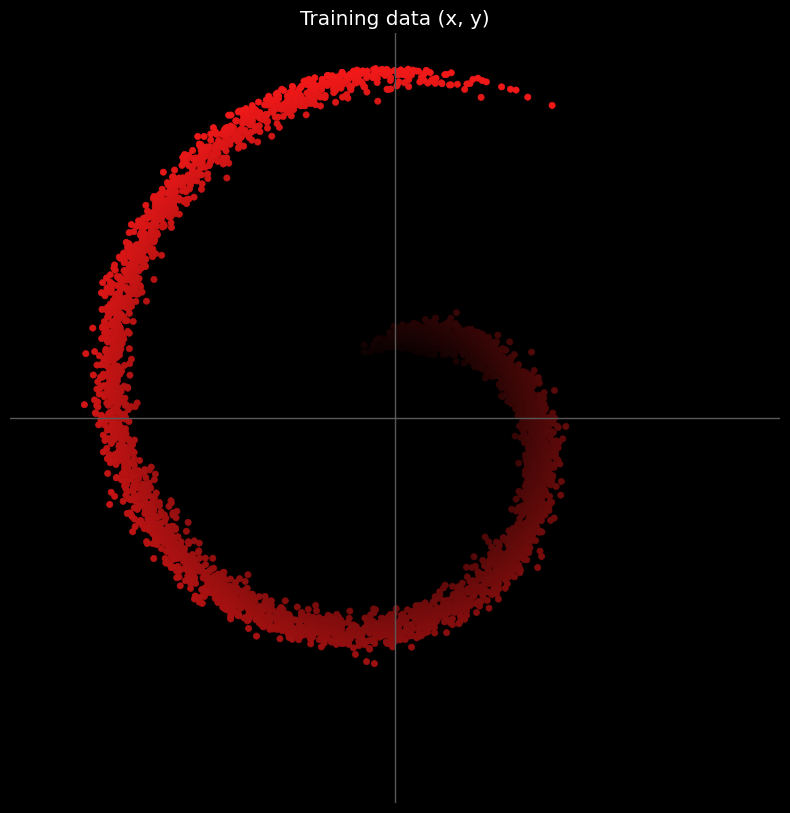

In [9]:
plot_data(X, y, point_colors=point_colors)
if save_plots:
    plt.savefig(os.path.join(output_dir, "data.png"), bbox_inches='tight')

## Prepare Dataset A

In [10]:
num_samples = 4096
batch_size = 128
num_dims = 2

N = num_samples
param_values = np.linspace(0, 1, N)

def curve_a_fn(u: np.ndarray):
    return (
        (0.8 * u + 0.2) * np.sin(1 * u * 2 * np.pi),
        (0.8 * u + 0.2) * np.cos(1 * u * 2 * np.pi),
    )

noise_std_a = [0.02, 0.02]

data_a, _ = sample_curve_data(
    param_values=param_values,
    curve_fn=curve_a_fn,
    noise_std=noise_std_a,
)

print("Dataset A structure:")
print(f"data_a shape: {data_a.shape}")
print(f"param_values shape: {param_values.shape}")
print("curve_a_fn defined: yes")

Dataset A structure:
data_a shape: (4096, 2)
param_values shape: (4096,)
curve_a_fn defined: yes


## Prepare Dataset B

In [11]:
data_b = np.copy(data_a)

def curve_b_fn(u: np.ndarray):
    x = u * 2.0 - 1.0
    y = x**3 - 0.5 * x - 0.5
    return (x, y)

noise_std_b = [0.02, 0.02]

data_b, _ = sample_curve_data(
    param_values=param_values,
    curve_fn=curve_b_fn,
    noise_std=noise_std_b,
)

batch_size = 64
pair_gen = paired_batch_generator(data_a=data_a, data_b=data_b, batch_size=batch_size)
(batch_a, batch_b), corr_target = next(pair_gen)

print("batch_a shape:", batch_a.shape)
print("batch_b shape:", batch_b.shape)

batch_a shape: (64, 2)
batch_b shape: (64, 2)


Text(0.5, 1.0, 'Curve Parameter')

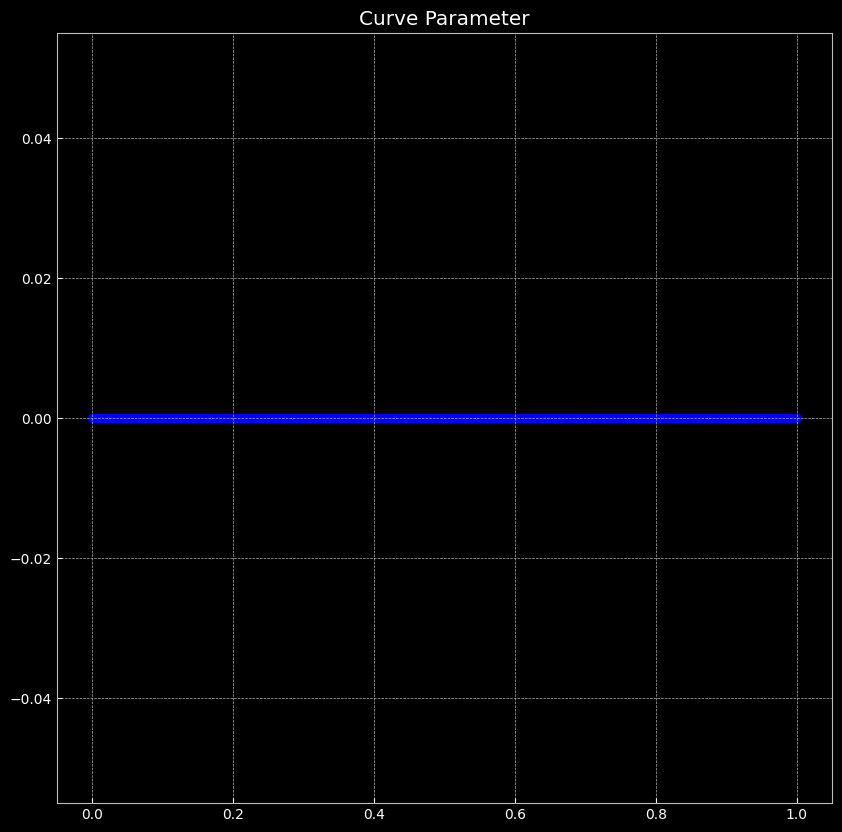

In [12]:
plt.scatter(param_values, np.zeros_like(param_values), color='blue', alpha=0.5, label='param_values')
plt.title('Curve Parameter')

In [13]:
np.array(curve_a_fn(param_values)).shape

(2, 4096)

Text(0.5, 1.0, 'Curve A')

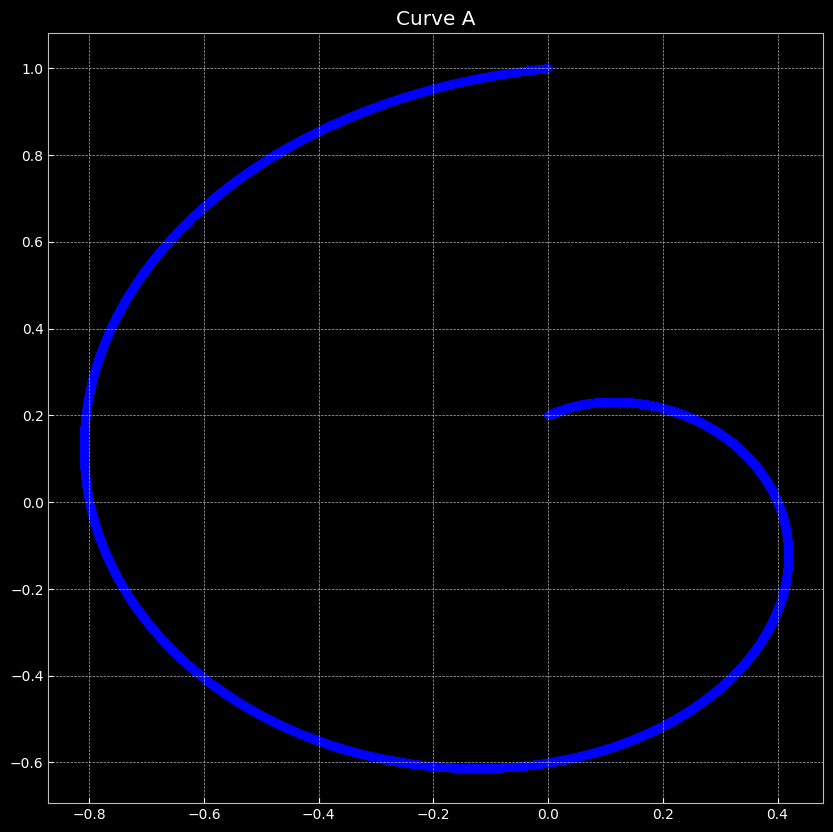

In [14]:
curve_a = curve_a_fn(param_values)
plt.scatter(curve_a[0], curve_a[1], color='blue', alpha=0.5, label='curve_a')
plt.title('Curve A')

In [12]:
np.array(curve_b_fn(param_values)).shape

(2, 4096)

Text(0.5, 1.0, 'Curve B')

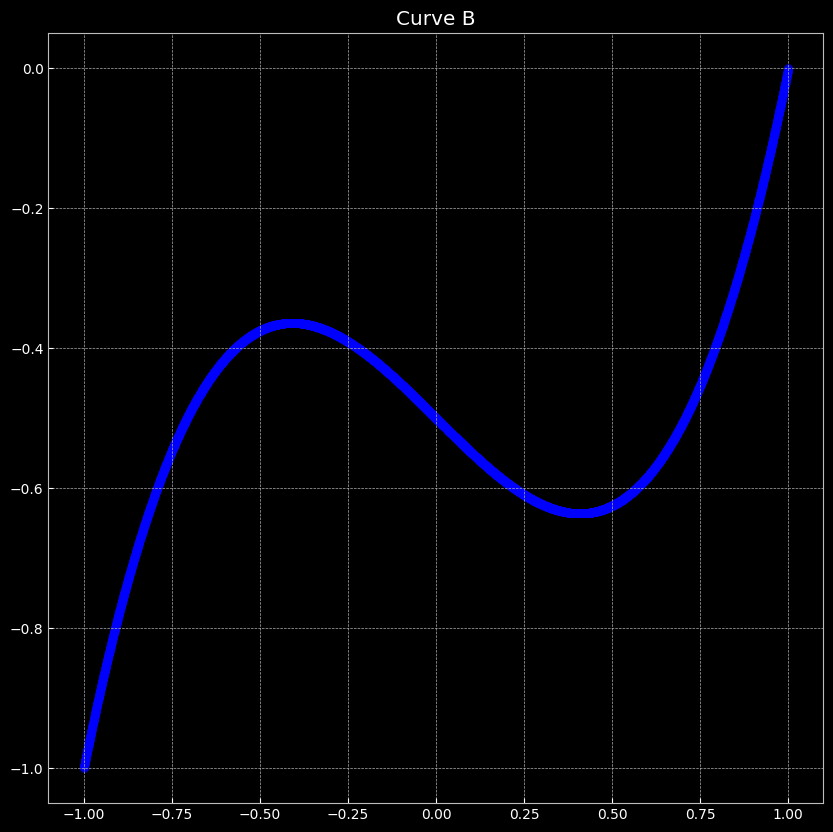

In [13]:
curve_b = curve_b_fn(param_values)
plt.scatter(curve_b[0], curve_b[1], color='blue', alpha=0.5, label='curve_b')
plt.title('Curve B')

Text(0.5, 1.0, 'Dataset A')

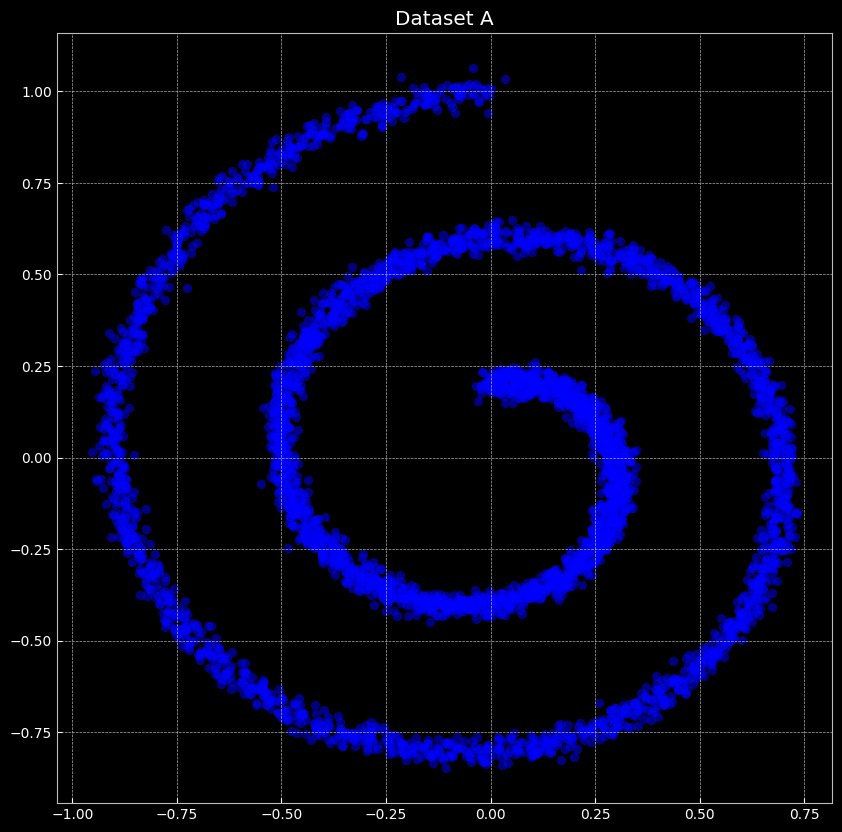

In [14]:
plt.scatter(data_a[:,0], data_a[:,1], color='blue', alpha=0.5, label='data_a')
plt.title('Dataset A')

Text(0.5, 1.0, 'Dataset B')

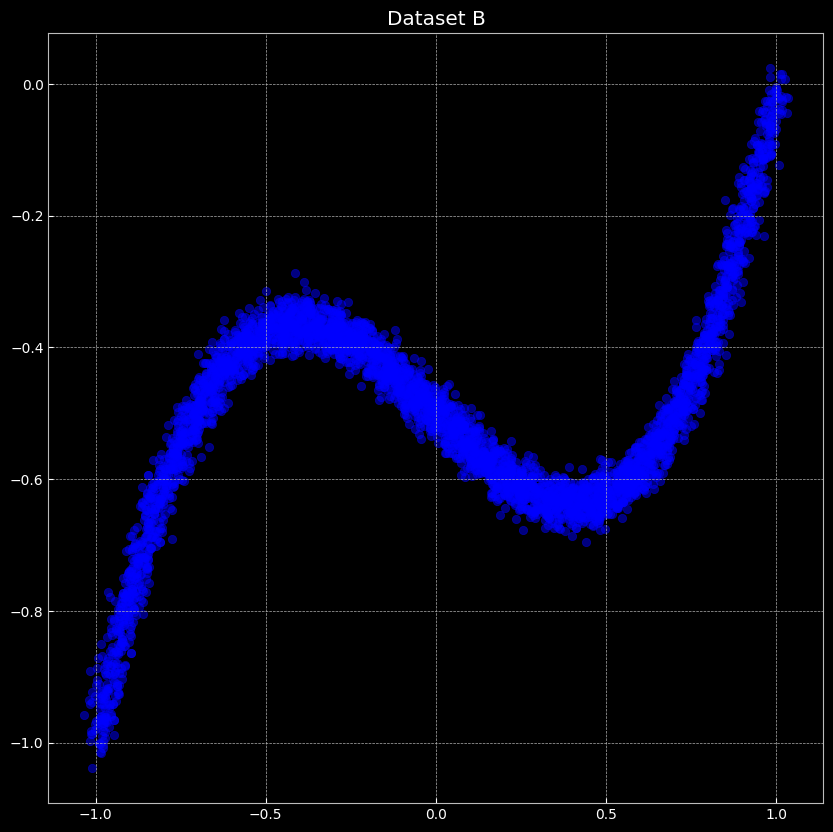

In [15]:
plt.scatter(data_b[:,0], data_b[:,1], color='blue', alpha=0.5, label='data_b')
plt.title('Dataset B')

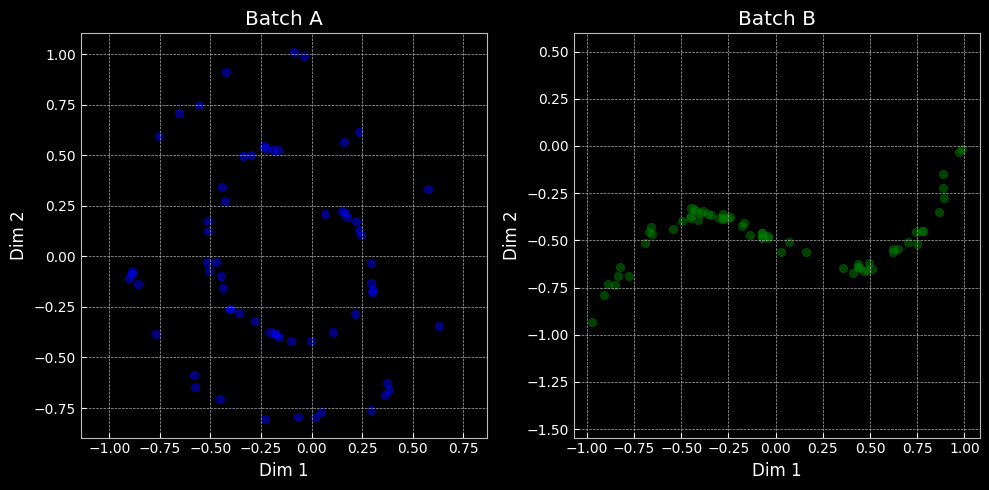

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(batch_a[:, 0], batch_a[:, 1], color='blue', alpha=0.5)
axs[0].set_title('Batch A')
axs[0].set_xlabel('Dim 1')
axs[0].set_ylabel('Dim 2')
axs[0].axis('equal')
axs[1].scatter(batch_b[:, 0], batch_b[:, 1], color='green', alpha=0.5)
axs[1].set_title('Batch B')
axs[1].set_xlabel('Dim 1')
axs[1].set_ylabel('Dim 2')
axs[1].axis('equal')
plt.tight_layout()
plt.show()

## Dual Flow Training

In [17]:
set_global_seed(seed=123)
layers_a = build_flow_layers(stage_count=10, num_dims=num_dims)
model_a = FlowModel(layers_a).to(device)
model_a.build(input_shape=[num_samples, num_dims])

layers_b = build_flow_layers(stage_count=2, num_dims=num_dims)
model_b = FlowModel(layers_b).to(device)
model_b.build(input_shape=[num_samples, num_dims])

print("Model A and Model B successfully built.")
model_a.summary()

Model A and Model B successfully built.
FlowModel(
  (0): ActivationNormalization
  (1): Reflection
  (2): AdditiveCoupling
  (3): CheckerBoardPermutation
  (4): AdditiveCoupling
  (5): CheckerBoardPermutation
  (6): ActivationNormalization
  (7): Reflection
  (8): AdditiveCoupling
  (9): CheckerBoardPermutation
  (10): AdditiveCoupling
  (11): CheckerBoardPermutation
  (12): ActivationNormalization
  (13): Reflection
  (14): AdditiveCoupling
  (15): CheckerBoardPermutation
  (16): AdditiveCoupling
  (17): CheckerBoardPermutation
  (18): ActivationNormalization
  (19): Reflection
  (20): AdditiveCoupling
  (21): CheckerBoardPermutation
  (22): AdditiveCoupling
  (23): CheckerBoardPermutation
  (24): ActivationNormalization
  (25): Reflection
  (26): AdditiveCoupling
  (27): CheckerBoardPermutation
  (28): AdditiveCoupling
  (29): CheckerBoardPermutation
  (30): ActivationNormalization
  (31): Reflection
  (32): AdditiveCoupling
  (33): CheckerBoardPermutation
  (34): AdditiveCoupling
 

In [18]:
class DualPairModel(torch.nn.Module):
    def __init__(self, model_a, model_b):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b

    def forward(self, input_a, input_b):
        output_a, jac_a = self.model_a(input_a)
        output_b, jac_b = self.model_b(input_b)
        return torch.cat([output_a, output_b, jac_a.unsqueeze(1), jac_b.unsqueeze(1)], dim=1)

dual_model = DualPairModel(model_a, model_b)
loss_function = SupervisedFactorLoss(dimensions_per_factor=[1, 1])
optimizer = torch.optim.Adam(list(model_a.parameters()) + list(model_b.parameters()), lr=0.001)

data_a_all = torch.tensor(data_a, device=device, dtype=torch.float64)
data_b_all = torch.tensor(data_b, device=device, dtype=torch.float64)

history = []
steps_per_epoch = 50
epochs = 500

In [19]:
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(steps_per_epoch):
        (batch_a_np, batch_b_np), corr_target_np = next(pair_gen)
        batch_a_t = torch.tensor(batch_a_np, device=device, dtype=torch.float64)
        batch_b_t = torch.tensor(batch_b_np, device=device, dtype=torch.float64)
        corr_target_t = torch.tensor(corr_target_np, device=device, dtype=torch.float64)

        predictions = dual_model(batch_a_t, batch_b_t)
        loss = loss_function(corr_target_t, predictions)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    history.append(epoch_loss / steps_per_epoch)
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:03d} | loss={history[-1]:.6f}")

print("Training completed")

Epoch 000 | loss=-0.481487
Epoch 050 | loss=-6.002195
Epoch 100 | loss=-6.451971
Epoch 150 | loss=-6.476860
Epoch 200 | loss=-6.468408
Epoch 250 | loss=-6.469717
Epoch 300 | loss=-6.467636
Epoch 350 | loss=-6.363748
Epoch 400 | loss=-6.616906
Epoch 450 | loss=-6.613650
Epoch 499 | loss=-6.580872
Training completed


In [26]:
checkpoint_path = os.path.join(output_dir, "dual_model_checkpoint_2.pt")

torch.save(
    {
        "epoch": epoch,
        "model_a_state_dict": model_a.state_dict(),
        "model_b_state_dict": model_b.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "batch_size": batch_size,
        "seed": seed,
    },
    checkpoint_path,
 )

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: output_04-spiral_classification\pytorch_dual_disentangle\dual_model_checkpoint_2.pt


In [ ]:
checkpoint_path = os.path.join(output_dir, "dual_model_checkpoint_2.pt")

checkpoint = torch.load(checkpoint_path, map_location=device)

model_a.load_state_dict(checkpoint["model_a_state_dict"])
model_b.load_state_dict(checkpoint["model_b_state_dict"])

if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

history = checkpoint.get("history", history)
batch_size = checkpoint.get("batch_size", batch_size)
seed = checkpoint.get("seed", seed)

dual_model.to(device).eval()

print(f"Loaded checkpoint from: {checkpoint_path}")
print(f"history_len={len(history)}, batch_size={batch_size}, seed={seed}")

Loaded checkpoint from: output_04-spiral_classification\pytorch_dual_disentangle\dual_model_checkpoint.pt
history_len=500, batch_size=64, seed=12345


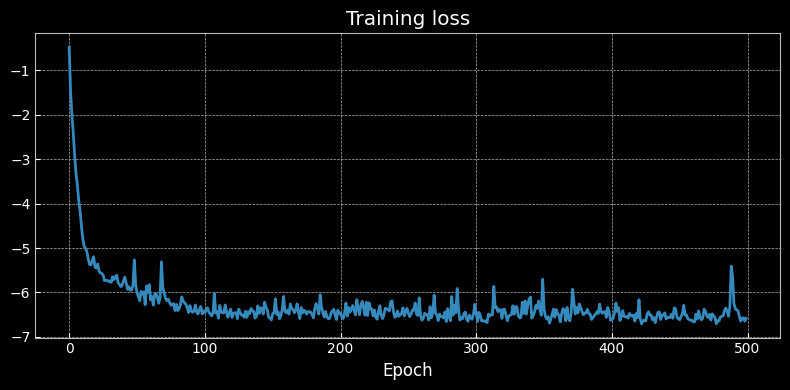

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

# Four-Panel Inference Check

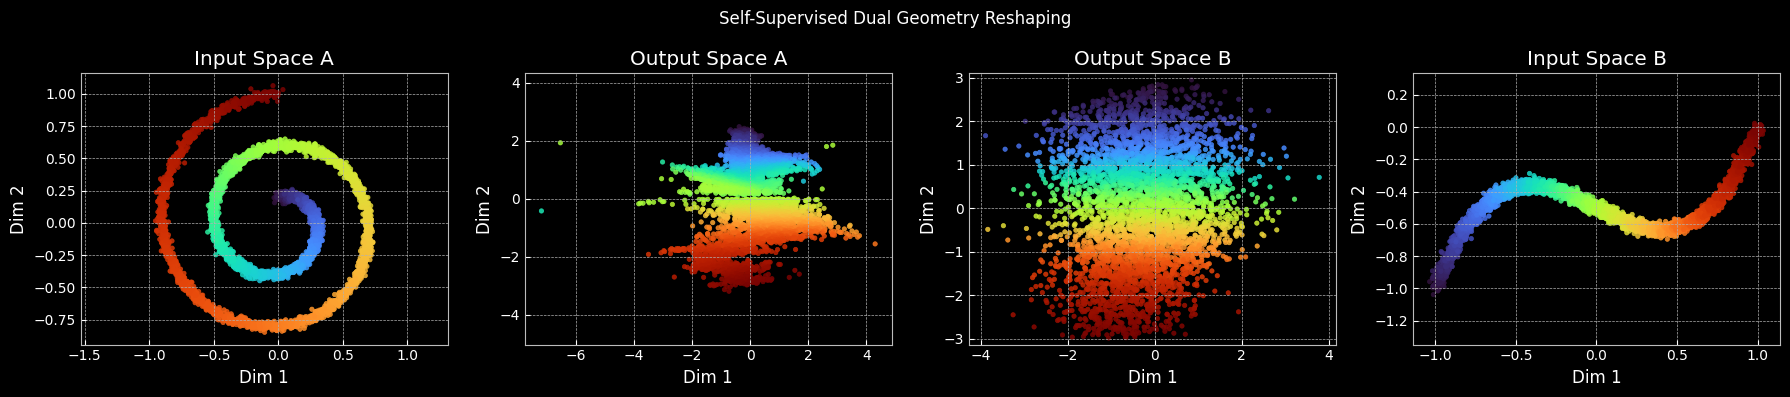

In [35]:
data_a_np = data_a if isinstance(data_a, np.ndarray) else data_a.numpy()
data_b_np = data_b if isinstance(data_b, np.ndarray) else data_b.numpy()

with torch.no_grad():
    output_a, _ = model_a(torch.tensor(data_a_np, device=device, dtype=torch.float64))
    output_b, _ = model_b(torch.tensor(data_b_np, device=device, dtype=torch.float64))

output_a = output_a.detach().cpu().numpy()
output_b = output_b.detach().cpu().numpy()
color_code = (param_values - np.min(param_values)) / (np.max(param_values) - np.min(param_values) + 1e-12)

def dual_geometry_reshaping_view(dim_1: float = None, dim_2: float = None):
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Self-Supervised Dual Geometry Reshaping')

    has_marker = (dim_1 is not None) and (dim_2 is not None)
    if has_marker:
        output_marker = torch.tensor([[dim_1, dim_2]], device=device, dtype=torch.float64)
        with torch.no_grad():
            input_a_marker = model_a.invert(output_marker).detach().cpu().numpy()[0]
            input_b_marker = model_b.invert(output_marker).detach().cpu().numpy()[0]

    axs[0].scatter(data_a_np[:, 0], data_a_np[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[0].scatter([input_a_marker[0]], [input_a_marker[1]], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[0].set_title('Input Space A')
    axs[0].set_xlabel('Dim 1')
    axs[0].set_ylabel('Dim 2')
    axs[0].axis('equal')

    axs[1].scatter(output_a[:, 0], output_a[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[1].scatter([dim_1], [dim_2], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[1].set_title('Output Space A')
    axs[1].set_xlabel('Dim 1')
    axs[1].set_ylabel('Dim 2')
    axs[1].axis('equal')

    axs[2].scatter(output_b[:, 0], output_b[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[2].scatter([dim_1], [dim_2], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[2].set_title('Output Space B')
    axs[2].set_xlabel('Dim 1')
    axs[2].set_ylabel('Dim 2')
    axs[2].axis('equal')

    axs[3].scatter(data_b_np[:, 0], data_b_np[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[3].scatter([input_b_marker[0]], [input_b_marker[1]], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[3].set_title('Input Space B')
    axs[3].set_xlabel('Dim 1')
    axs[3].set_ylabel('Dim 2')
    axs[3].axis('equal')

    plt.tight_layout()
    plt.show()

# interact(
#     dual_geometry_reshaping_view,
#     dim_1=(-2.0, 2.0, 0.1),
#     dim_2=(-2.0, 2.0, 0.1),
# )
dual_geometry_reshaping_view()